In [1]:
import os
import sys
from pathlib import Path

# Locate the project root robustly. This notebook is usually inside ./fe_multi_model or ./dff_HPF_multi_model.
def find_project_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "TACK_Tunnel_Data").exists():
            return candidate
    # Fallback for the original notebook layout: notebook folder is one level below project root.
    return start.parent

PROJECT_ROOT = find_project_root()
NOTEBOOK_DIR = Path.cwd().resolve()
DATASET_DIR = PROJECT_ROOT / "TACK_Tunnel_Data"
MODEL_DIR = NOTEBOOK_DIR / "models"
FIGURE_DIR = NOTEBOOK_DIR / "figures" / "feature_extraction" / "all_models"

for path in [str(PROJECT_ROOT), str(NOTEBOOK_DIR)]:
    if path not in sys.path:
        sys.path.append(path)

print("Notebook directory:", NOTEBOOK_DIR)
print("Project root:", PROJECT_ROOT)
print("Dataset directory:", DATASET_DIR, "exists=", DATASET_DIR.exists())
print("Model directory:", MODEL_DIR, "exists=", MODEL_DIR.exists())
print("Figure directory:", FIGURE_DIR)


Notebook directory: /home/yash/Documents/GitHub/CSCI5527-final/fe_multi_model
Project root: /home/yash/Documents/GitHub/CSCI5527-final
Dataset directory: /home/yash/Documents/GitHub/CSCI5527-final/TACK_Tunnel_Data exists= True
Model directory: /home/yash/Documents/GitHub/CSCI5527-final/fe_multi_model/models exists= True
Figure directory: /home/yash/Documents/GitHub/CSCI5527-final/fe_multi_model/figures/feature_extraction/all_models


In [2]:
import math
import shutil
from dataclasses import dataclass
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch
import torch.nn.functional as F
import segmentation_models_pytorch as smp

# Keep the two preprocessing modules separate. Using aliases avoids accidental override of TunnelDataPipeline.
from preprocessing import TunnelDataPipeline as StandardTunnelDataPipeline
from preprocessing_wi_filter import TunnelDataPipeline as FilteredTunnelDataPipeline


In [3]:
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("cuDNN available:", torch.backends.cudnn.is_available())

n_gpu = torch.cuda.device_count()
print(f"Total GPUs available: {n_gpu}")
for i in range(n_gpu):
    print(f"Device {i}: {torch.cuda.get_device_name(i)}")

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using {device} device")

# Do not set torch.set_default_device here. Keeping tensors on CPU by default avoids surprises in FastAI/Pandas/OpenCV code.


PyTorch: 2.11.0+cu126
CUDA available: True
cuDNN available: True
Total GPUs available: 1
Device 0: NVIDIA GeForce RTX 2060 SUPER
Using cuda:0 device


In [4]:
DATA_SPLIT_CONFIG = {
    "train_files": ["TA_train.csv", "TB_train.csv", "TC_train.csv"],
    "val_files": ["TA_val.csv", "TB_val.csv", "TC_val.csv"],
    "test_files": ["TA_test.csv", "TB_test.csv", "TC_test.csv"],
}

MODEL_CONFIGS = [
    {
        "key": "imagenet",
        "model_name": "Unet-resnet34-imagenet_Multi-Domain",
        "processed_version": None,
        "pipeline_type": "standard",
        "use_imagenet_stats": True,
    },
    {
        "key": "no_weight",
        "model_name": "Unet-resnet34-no_weight_Multi-Domain",
        "processed_version": None,
        "pipeline_type": "standard",
        "use_imagenet_stats": False,
    },
    {
        "key": "sobelxy",
        "model_name": "Unet-resnet34-sobelxy_Multi-Domain",
        "processed_version": "4_img_sobelxy",
        "pipeline_type": "filtered",
        "use_imagenet_stats": False,
    },
    {
        "key": "sobelmaglap",
        "model_name": "Unet-resnet34-sobelmaglap_Multi-Domain",
        "processed_version": "4_img_sobelmaglap",
        "pipeline_type": "filtered",
        "use_imagenet_stats": False,
    },
    {
        "key": "sobelmag_gabor",
        "model_name": "Unet-resnet34-sobelmag_gabor_Multi-Domain",
        "processed_version": "4_img_sobelmag_gabor",
        "pipeline_type": "filtered",
        "use_imagenet_stats": False,
    },
]

for cfg in MODEL_CONFIGS:
    ckpt = MODEL_DIR / f"{cfg['model_name']}.pth"
    processed = cfg["processed_version"]
    processed_status = "standard RGB input" if processed is None else f"{DATASET_DIR / processed}"
    print(f"{cfg['key']:<16} checkpoint exists={ckpt.exists()} | input={processed_status}")


imagenet         checkpoint exists=True | input=standard RGB input
no_weight        checkpoint exists=True | input=standard RGB input
sobelxy          checkpoint exists=True | input=/home/yash/Documents/GitHub/CSCI5527-final/TACK_Tunnel_Data/4_img_sobelxy
sobelmaglap      checkpoint exists=True | input=/home/yash/Documents/GitHub/CSCI5527-final/TACK_Tunnel_Data/4_img_sobelmaglap
sobelmag_gabor   checkpoint exists=True | input=/home/yash/Documents/GitHub/CSCI5527-final/TACK_Tunnel_Data/4_img_sobelmag_gabor


In [5]:
def processed_suffix(processed_version: str) -> str:
    """Map 4_img_sobelxy -> _sobelxy, 4_img_sobelmaglap -> _sobelmaglap, etc."""
    if not processed_version.startswith("4_img"):
        return "_" + processed_version
    return processed_version.replace("4_img", "", 1)


def ensure_expected_processed_filenames(project_root: Path, processed_version: str, max_preview: int = 5) -> None:
    """Create symlink aliases for filtered images when the folder uses unsuffixed filenames."""
    folder = project_root / "TACK_Tunnel_Data" / processed_version
    if not folder.exists():
        raise FileNotFoundError(
            f"Missing processed image folder: {folder}\n"
            "Run prefiltering.py from the project root before running the feature extraction notebook."
        )

    suffix = processed_suffix(processed_version)
    pngs = sorted(folder.glob("*.png"))
    if not pngs:
        raise FileNotFoundError(f"No PNG files found in processed image folder: {folder}")

    created = 0
    for src in pngs:
        # If the file already has the expected suffix, it is already compatible.
        if src.stem.endswith(suffix):
            continue

        alias = src.with_name(f"{src.stem}{suffix}{src.suffix}")
        if alias.exists():
            continue

        try:
            # Relative symlinks keep the folder portable if the whole repo is moved.
            alias.symlink_to(src.name)
            created += 1
        except OSError:
            try:
                os.link(src, alias)
                created += 1
            except OSError:
                # Last fallback. This should rarely be needed on Linux, but keeps the notebook robust.
                shutil.copy2(src, alias)
                created += 1

    final_pngs = sorted(folder.glob("*.png"))
    suffixed = [p for p in final_pngs if p.stem.endswith(suffix)]

    print(f"\nProcessed folder: {folder}")
    print(f"  expected suffix: {suffix}")
    print(f"  png count: {len(final_pngs)}")
    print(f"  suffixed/compatible png count: {len(suffixed)}")
    print(f"  aliases created this run: {created}")
    print("  preview:")
    for p in final_pngs[:max_preview]:
        print("   -", p.name)


def validate_dataframe(name: str, df: pd.DataFrame, processed_version: Optional[str] = None) -> None:
    if df is None or len(df) == 0:
        detail = "standard image folder" if processed_version is None else processed_version
        raise ValueError(
            f"{name} is empty after mask/image sanitization for {detail}. "
            "This usually means image filenames do not match the CSV rows or the processed folder is missing."
        )
    print(f"{name}: {len(df)} rows")


def build_dataloaders_for_config(
    cfg: Dict,
    base_dir: Path,
    split_config: Dict,
    batch_size: int = 16,
    img_size: int = 512,
):
    dataset_folder = base_dir / "TACK_Tunnel_Data"
    csv_source_dir = dataset_folder / "2_model_input"
    raw_mask_dir = dataset_folder / "3_mask"
    processed_version = cfg["processed_version"]

    if cfg["pipeline_type"] == "filtered":
        ensure_expected_processed_filenames(base_dir, processed_version)
        pipeline = FilteredTunnelDataPipeline(
            base_dir=str(dataset_folder),
            original_mask_dir=str(raw_mask_dir),
            processed_img_subdir=processed_version,
        )
    else:
        pipeline = StandardTunnelDataPipeline(
            base_dir=str(dataset_folder),
            original_mask_dir=str(raw_mask_dir),
        )

    print(f"\n=== Building dataloaders for {cfg['model_name']} ===")
    print("Loading CSV metadata...")
    df_train_val, df_test = pipeline.load_csv_data(
        csv_source_dir=str(csv_source_dir),
        train_files=split_config["train_files"],
        val_files=split_config["val_files"],
        test_files=split_config["test_files"],
    )

    print("Sanitizing training and validation masks/images...")
    df_train_val_ready = pipeline.sanitize_masks(df_train_val, class_pixel_value=40)
    validate_dataframe("train/val dataframe", df_train_val_ready, processed_version)

    print("Sanitizing test masks/images...")
    df_test_ready = pipeline.sanitize_masks(df_test, class_pixel_value=40)
    validate_dataframe("test dataframe", df_test_ready, processed_version)

    if cfg["use_imagenet_stats"]:
        custom_stats = None
        print("Normalization: ImageNet stats")
    else:
        print("Calculating custom dataset statistics...")
        custom_stats = pipeline.calculate_training_stats(df_train_val_ready)
        print("Custom stats:", custom_stats)

    print("Generating dataloaders...")
    train_dl, val_dl, test_dl = pipeline.get_dataloaders(
        train_val_df=df_train_val_ready,
        test_df=df_test_ready,
        bs=batch_size,
        img_size=img_size,
        custom_stats=custom_stats,
    )

    print("Pipeline ready:")
    print(f" - Training batches: {len(train_dl)}")
    print(f" - Validation batches: {len(val_dl)}")
    print(f" - Testing batches: {len(test_dl)}")

    # Try test first, then validation, then train for sample selection.
    # Keeping the split names lets the final figure report exactly where the displayed sample came from.
    return [("test", test_dl), ("val", val_dl), ("train", train_dl)], custom_stats


In [6]:
# Build every dataloader that has a matching checkpoint and required image folder.
# STRICT=False lets the notebook continue through all available models instead of stopping at the first issue.
STRICT = False

dataloader_bundle = {}
dataloader_errors = {}

for cfg in MODEL_CONFIGS:
    ckpt_path = MODEL_DIR / f"{cfg['model_name']}.pth"
    if not ckpt_path.exists():
        msg = f"Skipping {cfg['model_name']}: checkpoint not found at {ckpt_path}"
        print("\n" + msg)
        dataloader_errors[cfg["key"]] = msg
        continue

    try:
        dataloaders, custom_stats = build_dataloaders_for_config(
            cfg,
            base_dir=PROJECT_ROOT,
            split_config=DATA_SPLIT_CONFIG,
            batch_size=16,
            img_size=512,
        )
        dataloader_bundle[cfg["key"]] = {
            "config": cfg,
            "dataloaders": dataloaders,
            "custom_stats": custom_stats,
        }
    except Exception as exc:
        dataloader_errors[cfg["key"]] = repr(exc)
        print(f"\nFAILED to build dataloaders for {cfg['model_name']}: {exc}")
        if STRICT:
            raise

print("\n=== Dataloader build summary ===")
print("Ready:", list(dataloader_bundle.keys()))
print("Errors/skipped:", dataloader_errors)

if not dataloader_bundle:
    raise RuntimeError("No dataloaders were built. Check PROJECT_ROOT, TACK_Tunnel_Data, CSV files, and model checkpoints.")



=== Building dataloaders for Unet-resnet34-imagenet_Multi-Domain ===
Loading CSV metadata...
Sanitizing training and validation masks/images...


Sanitizing Masks: 100%|██████████| 1360/1360 [00:00<00:00, 31437.05it/s]


train/val dataframe: 1360 rows
Sanitizing test masks/images...


Sanitizing Masks: 100%|██████████| 156/156 [00:00<00:00, 23951.66it/s]

test dataframe: 156 rows
Normalization: ImageNet stats
Generating dataloaders...


...

train/val dataframe: 1360 rows
Sanitizing test masks/images...


Sanitizing Masks: 100%|██████████| 156/156 [00:00<00:00, 26783.11it/s]


test dataframe: 156 rows
Calculating custom dataset statistics...
Calculating custom dataset statistics...


Computing Stats: 100%|██████████| 1058/1058 [00:21<00:00, 49.95it/s]

Custom stats: (tensor([0.4883, 0.1205, 0.2960], dtype=torch.float64), tensor([0.1079, 0.0837, 0.1057], dtype=torch.float64))
Generating dataloaders...
Pipeline ready:
 - Training batches: 66
 - Validation batches: 19
 - Testing batches: 10

=== Dataloader build summary ===
Ready: ['imagenet', 'no_weight', 'sobelxy', 'sobelmaglap', 'sobelmag_gabor']
Errors/skipped: {}


In [7]:
def clean_state_dict_keys(state_dict: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
    """Handle checkpoints saved from DataParallel or wrapper modules."""
    cleaned = {}
    for key, value in state_dict.items():
        new_key = key
        for prefix in ["module.", "model."]:
            if new_key.startswith(prefix):
                new_key = new_key[len(prefix):]
        cleaned[new_key] = value
    return cleaned


def load_unet_resnet34_model(model_name: str, device: torch.device, model_dir: Path = MODEL_DIR):
    checkpoint_path = model_dir / f"{model_name}.pth"
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Missing checkpoint: {checkpoint_path}")

    # encoder_weights=None avoids an internet/cache dependency. The checkpoint overwrites the model weights.
    model = smp.Unet("resnet34", encoder_weights=None, classes=2)
    checkpoint = torch.load(checkpoint_path, map_location=device)

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        checkpoint = checkpoint["model_state_dict"]
    elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        checkpoint = checkpoint["state_dict"]

    if not isinstance(checkpoint, dict):
        raise TypeError(f"Unsupported checkpoint format in {checkpoint_path}")

    checkpoint = clean_state_dict_keys(checkpoint)
    model.load_state_dict(checkpoint, strict=True)
    model.to(device)
    model.eval()
    return model


def get_resnet34_feature_layers(model):
    return {
        "low": model.encoder.layer1[-1],
        "mid": model.encoder.layer3[-1],
        "high": model.encoder.layer4[-1],
        "classifier": model.segmentation_head,
    }


model_runs = []
model_errors = {}

for cfg in MODEL_CONFIGS:
    if cfg["key"] not in dataloader_bundle:
        continue

    try:
        model = load_unet_resnet34_model(cfg["model_name"], device)
        model_runs.append({
            "config": cfg,
            "model": model,
            "model_name": cfg["model_name"],
            "feature_layers": get_resnet34_feature_layers(model),
            "dataloaders": dataloader_bundle[cfg["key"]]["dataloaders"],
            "custom_stats": dataloader_bundle[cfg["key"]]["custom_stats"],
        })
        print(f"Loaded: {cfg['model_name']}")
    except Exception as exc:
        model_errors[cfg["key"]] = repr(exc)
        print(f"FAILED to load {cfg['model_name']}: {exc}")
        if STRICT:
            raise

print("\nModels ready:", [run["model_name"] for run in model_runs])
print("Model errors:", model_errors)

if not model_runs:
    raise RuntimeError("No models were loaded. Check that ./models contains the expected .pth files.")


Loaded: Unet-resnet34-imagenet_Multi-Domain
Loaded: Unet-resnet34-no_weight_Multi-Domain
Loaded: Unet-resnet34-sobelxy_Multi-Domain
Loaded: Unet-resnet34-sobelmaglap_Multi-Domain
Loaded: Unet-resnet34-sobelmag_gabor_Multi-Domain

Models ready: ['Unet-resnet34-imagenet_Multi-Domain', 'Unet-resnet34-no_weight_Multi-Domain', 'Unet-resnet34-sobelxy_Multi-Domain', 'Unet-resnet34-sobelmaglap_Multi-Domain', 'Unet-resnet34-sobelmag_gabor_Multi-Domain']
Model errors: {}


In [8]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)


def unpack_batch(batch):
    if isinstance(batch, dict):
        image = None
        target = None
        for key in ["image", "images", "x", "input", "inputs"]:
            if key in batch:
                image = batch[key]
                break
        for key in ["mask", "masks", "target", "targets", "y", "label", "labels"]:
            if key in batch:
                target = batch[key]
                break
        if image is None:
            raise KeyError("Could not find an image tensor in the batch dictionary.")
        return image, target

    if isinstance(batch, (list, tuple)):
        image = batch[0]
        target = batch[1] if len(batch) > 1 else None
        return image, target

    return batch, None


def _named_dataloader(entry, index):
    """Return (split_name, dataloader) from either a raw dataloader or a named tuple/dict."""
    if isinstance(entry, dict):
        name = entry.get("name") or entry.get("split") or f"dataloader_{index}"
        dataloader = entry.get("dataloader") or entry.get("dl") or entry.get("loader")
        if dataloader is None:
            raise KeyError(f"Dataloader dictionary for {name} must contain 'dataloader', 'dl', or 'loader'.")
        return str(name), dataloader

    if isinstance(entry, (list, tuple)) and len(entry) == 2 and isinstance(entry[0], str):
        return entry[0], entry[1]

    return f"dataloader_{index}", entry


def first_available_sample(dataloaders, device, prefer_positive_mask=True, max_batches_per_loader=50):
    """Return one sample and the split name.

    The notebook receives dataloaders in this order: test, val, train. It searches in that order,
    preferring an image with crack pixels when masks are available. If no positive-mask sample is
    found, it falls back to the first valid sample from the earliest working split.
    """
    fallback = None
    last_error = None

    for loader_index, entry in enumerate(dataloaders):
        split_name, dataloader = _named_dataloader(entry, loader_index)
        try:
            for batch_idx, batch in enumerate(dataloader):
                if batch_idx >= max_batches_per_loader:
                    break

                image, target = unpack_batch(batch)
                if image.ndim == 3:
                    image = image.unsqueeze(0)

                if target is not None and hasattr(target, "ndim") and target.ndim == 2:
                    target = target.unsqueeze(0)

                if fallback is None:
                    fallback_target = target[:1].to(device) if target is not None and hasattr(target, "to") else target
                    fallback = (image[:1].to(device), fallback_target, split_name)

                if prefer_positive_mask and target is not None and hasattr(target, "sum"):
                    target_cpu = target.detach().cpu() if torch.is_tensor(target) else target
                    for i in range(min(len(image), len(target_cpu))):
                        if torch.as_tensor(target_cpu[i]).sum() > 0:
                            sample_target = target[i:i+1].to(device) if hasattr(target, "to") else target
                            return image[i:i+1].to(device), sample_target, split_name
                elif not prefer_positive_mask:
                    sample_target = target[:1].to(device) if target is not None and hasattr(target, "to") else target
                    return image[:1].to(device), sample_target, split_name
        except Exception as exc:
            last_error = exc
            print(f"Skipping {split_name} dataloader because it could not provide a sample: {exc}")

    if fallback is not None:
        return fallback

    raise RuntimeError("No dataloader produced a valid sample.") from last_error


def get_expected_input_channels(model):
    """Infer the number of channels expected by the first convolution."""
    for module in model.modules():
        if isinstance(module, torch.nn.Conv2d):
            return int(module.in_channels)
    return 3


def ensure_model_input_channels(image_batch, expected_channels=3):
    """Make grayscale tensors compatible with ResNet-style 3-channel checkpoints.

    The source images are grayscale. Some dataloaders return them as [B, 1, H, W];
    others return [B, 3, H, W], where each channel is a grayscale signal. The model
    checkpoints expect 3 input channels, so a single grayscale channel is repeated.
    """
    if image_batch.ndim == 3:
        image_batch = image_batch.unsqueeze(0)

    channels = image_batch.shape[1]
    if channels == expected_channels:
        return image_batch

    if channels == 1 and expected_channels == 3:
        return image_batch.repeat(1, 3, 1, 1)

    if channels > expected_channels:
        print(f"Input has {channels} channels; using the first {expected_channels} channels for this model.")
        return image_batch[:, :expected_channels]

    if channels < expected_channels:
        repeats = int(np.ceil(expected_channels / channels))
        print(f"Input has {channels} channels; repeating/cropping to {expected_channels} channels for this model.")
        return image_batch.repeat(1, repeats, 1, 1)[:, :expected_channels]

    raise ValueError(f"Could not adapt input with {channels} channels to expected {expected_channels} channels.")


def _extract_mean_std(custom_stats, channels):
    if custom_stats is None:
        if channels == 3:
            return IMAGENET_MEAN, IMAGENET_STD
        return np.zeros(channels, dtype=np.float32), np.ones(channels, dtype=np.float32)

    if isinstance(custom_stats, dict):
        mean = custom_stats.get("mean", custom_stats.get("means", None))
        std = custom_stats.get("std", custom_stats.get("stds", None))
    elif isinstance(custom_stats, (list, tuple)) and len(custom_stats) == 2:
        mean, std = custom_stats
    else:
        mean, std = None, None

    if mean is None or std is None:
        if channels == 3:
            return IMAGENET_MEAN, IMAGENET_STD
        return np.zeros(channels, dtype=np.float32), np.ones(channels, dtype=np.float32)

    if torch.is_tensor(mean):
        mean = mean.detach().cpu().numpy()
    if torch.is_tensor(std):
        std = std.detach().cpu().numpy()

    mean = np.asarray(mean, dtype=np.float32).reshape(-1)
    std = np.asarray(std, dtype=np.float32).reshape(-1)

    if mean.size == 1 and channels > 1:
        mean = np.repeat(mean, channels)
    if std.size == 1 and channels > 1:
        std = np.repeat(std, channels)

    if mean.size != channels or std.size != channels:
        if channels == 3:
            return IMAGENET_MEAN, IMAGENET_STD
        return np.zeros(channels, dtype=np.float32), np.ones(channels, dtype=np.float32)

    return mean, std


def denormalize_image_tensor(image_tensor, custom_stats=None):
    """Denormalize [C,H,W] or [1,C,H,W] image tensor without assuming RGB semantics."""
    image = image_tensor.detach().cpu().float()
    if image.ndim == 4:
        image = image[0]

    channels = image.shape[0]
    mean, std = _extract_mean_std(custom_stats, channels)
    mean = torch.tensor(mean, dtype=image.dtype, device=image.device).view(-1, 1, 1)
    std = torch.tensor(std, dtype=image.dtype, device=image.device).view(-1, 1, 1)
    return (image * std + mean).clamp(0, 1)


def tensor_to_display_gray(image_tensor, custom_stats=None, display_channel=0):
    """Return a 2D grayscale image for plotting.

    These data are grayscale, not RGB. If a tensor has 3 channels, those channels
    are interpreted as separate grayscale signals. Channel 0 is used for the input
    display because the HPF preprocessing stores the original image there.
    """
    image = denormalize_image_tensor(image_tensor, custom_stats=custom_stats)
    display_channel = min(display_channel, image.shape[0] - 1)
    return image[display_channel].numpy()


def input_channel_grid(image_tensor, custom_stats=None, tile_size=110, gap=6, max_channels=3):
    """Optional compact view of the grayscale input channels."""
    image = denormalize_image_tensor(image_tensor, custom_stats=custom_stats)
    n_channels = min(int(image.shape[0]), max_channels)
    grid_h = tile_size
    grid_w = n_channels * tile_size + (n_channels - 1) * gap
    grid = np.zeros((grid_h, grid_w), dtype=np.float32)
    for i in range(n_channels):
        ch = image[i].unsqueeze(0).unsqueeze(0)
        ch = F.interpolate(ch, size=(tile_size, tile_size), mode="bilinear", align_corners=False)
        grid[:, i * (tile_size + gap): i * (tile_size + gap) + tile_size] = ch.squeeze().numpy()
    return grid


def normalize_array(array, eps=1e-8):
    array = np.asarray(array, dtype=np.float32)
    return (array - array.min()) / (array.max() - array.min() + eps)


def feature_activation_grid(activation, n_tiles=16, tile_size=68, cols=4, gap=4):
    """Create a fixed-size grid of the top activation channels.

    This always allocates the requested number of tile slots. If a layer has fewer channels
    than requested, remaining slots stay blank, preserving the visual layout.
    """
    features = activation.detach().float().cpu()
    if features.ndim == 4:
        features = features[0]

    channels = int(features.shape[0])
    requested_tiles = int(n_tiles)
    cols = int(cols)
    rows = math.ceil(requested_tiles / cols)
    n_select = min(requested_tiles, channels)

    scores = features.flatten(1).std(dim=1)
    selected = torch.topk(scores, k=n_select).indices.tolist()

    grid_h = rows * tile_size + (rows - 1) * gap
    grid_w = cols * tile_size + (cols - 1) * gap
    grid = np.zeros((grid_h, grid_w), dtype=np.float32)

    for tile_idx, channel_idx in enumerate(selected):
        row = tile_idx // cols
        col = tile_idx % cols
        fmap = features[channel_idx].unsqueeze(0).unsqueeze(0)
        fmap = F.interpolate(fmap, size=(tile_size, tile_size), mode="bilinear", align_corners=False)
        fmap = normalize_array(fmap.squeeze().numpy())
        y0 = row * (tile_size + gap)
        x0 = col * (tile_size + gap)
        grid[y0:y0 + tile_size, x0:x0 + tile_size] = fmap

    return grid


def binary_mask_from_target(target, target_size=None):
    """Convert a dataloader mask to a 2D binary crack mask: black background, white crack."""
    if target is None:
        return None

    mask = target.detach().float().cpu() if torch.is_tensor(target) else torch.as_tensor(target).float()

    # Accept [B,H,W], [B,1,H,W], [H,W], or class-score style tensors.
    if mask.ndim == 4:
        mask = mask[0]
    if mask.ndim == 3:
        if mask.shape[0] == 1:
            mask = mask[0]
        elif mask.shape[-1] == 1:
            mask = mask[..., 0]
        else:
            mask = torch.argmax(mask, dim=0).float()
    if mask.ndim != 2:
        mask = mask.squeeze()
    if mask.ndim != 2:
        raise ValueError(f"Could not convert target with shape {tuple(mask.shape)} to a 2D mask.")

    mask = (mask > 0).float()
    if target_size is not None and tuple(mask.shape) != tuple(target_size):
        mask = F.interpolate(mask[None, None], size=tuple(target_size), mode="nearest")[0, 0]

    return mask.numpy().astype(np.float32)


def prediction_mask_from_logits(logits, target_size=None):
    """Convert model logits to a 2D binary predicted crack mask: black background, white crack."""
    pred_logits = logits.detach().float().cpu()
    if pred_logits.ndim == 4:
        pred_logits = pred_logits[0]

    if pred_logits.shape[0] == 1:
        pred = (torch.sigmoid(pred_logits[0]) > 0.5).float()
    else:
        pred = torch.argmax(pred_logits, dim=0).float()

    pred = (pred > 0).float()
    if target_size is not None and tuple(pred.shape) != tuple(target_size):
        pred = F.interpolate(pred[None, None], size=tuple(target_size), mode="nearest")[0, 0]

    return pred.numpy().astype(np.float32)


def output_prediction_grid(logits, tile_size=120):
    """Return only the binary predicted crack mask.

    The earlier version showed both a confidence/probability map and a prediction map. The
    confidence map could look like a white image with a dark crack, so it is intentionally removed.
    """
    pred = torch.as_tensor(prediction_mask_from_logits(logits)).float()
    pred = F.interpolate(pred[None, None], size=(tile_size, tile_size), mode="nearest")[0, 0]
    return pred.numpy().astype(np.float32)


def pretty_model_title(model_name: str) -> str:
    mapping = {
        "Unet-resnet34-imagenet_Multi-Domain": "Imagenet",
        "Unet-resnet34-no_weight_Multi-Domain": "No Weight",
        "Unet-resnet34-sobelmag_gabor_Multi-Domain": "Sobel Magnitude + Gabor",
        "Unet-resnet34-sobelmaglap_Multi-Domain": "Sobel Magnitude + Laplacian",
        "Unet-resnet34-sobelxy_Multi-Domain": "Sobel X/Y",
    }
    return mapping.get(model_name, model_name)


In [11]:
def extract_multilevel_features(model, image_batch, feature_layers):
    activations = {}
    handles = []

    def capture(name):
        def hook(_module, _inputs, output):
            activations[name] = output.detach()
        return hook

    for name in ["low", "mid", "high"]:
        handles.append(feature_layers[name].register_forward_hook(capture(name)))

    try:
        model.eval()
        with torch.no_grad():
            logits = model(image_batch)
    finally:
        for handle in handles:
            handle.remove()

    return activations, logits


def make_feature_extraction_figure(
    model,
    model_name,
    dataloaders,
    feature_layers,
    device,
    custom_stats=None,
    save_dir="figures/feature_extraction",
    save=True,
    dpi=600,
):
    raw_image_batch, target_batch, sample_split = first_available_sample(dataloaders, device)
    expected_channels = get_expected_input_channels(model)
    image_batch = ensure_model_input_channels(raw_image_batch, expected_channels=expected_channels)

    print(f"Input tensor for {model_name}: raw shape={tuple(raw_image_batch.shape)}, model shape={tuple(image_batch.shape)}")
    print(f"Final figure sample split: {sample_split}")
    print("Displaying channel 0 as grayscale. The channels are not treated as RGB.")

    activations, logits = extract_multilevel_features(model, image_batch, feature_layers)

    input_gray = tensor_to_display_gray(image_batch, custom_stats=custom_stats, display_channel=0)
    target_size = input_gray.shape
    gt_mask = binary_mask_from_target(target_batch, target_size=target_size)
    pred_mask = prediction_mask_from_logits(logits, target_size=target_size)

    # Use the same number of maps, columns, and tile size for each feature level.
    feature_grid_tiles = 16
    feature_grid_cols = 4
    feature_tile_size = 68
    low_grid = feature_activation_grid(activations["low"], n_tiles=feature_grid_tiles, tile_size=feature_tile_size, cols=feature_grid_cols)
    mid_grid = feature_activation_grid(activations["mid"], n_tiles=feature_grid_tiles, tile_size=feature_tile_size, cols=feature_grid_cols)
    high_grid = feature_activation_grid(activations["high"], n_tiles=feature_grid_tiles, tile_size=feature_tile_size, cols=feature_grid_cols)

    # Vertical, white-background layout.
    fig = plt.figure(figsize=(7.25, 13.25), facecolor="white")
    gs = fig.add_gridspec(
        nrows=5,
        ncols=1,
        height_ratios=[1.35, 2.05, 2.05, 2.05, 0.12],
        hspace=0.38,
        top=0.94,
        bottom=0.035,
        left=0.055,
        right=0.945,
    )

    fig.suptitle(
        f"{pretty_model_title(model_name)}\nLow-, Mid-, and High-Level Feature Activations",
        fontsize=14,
        fontweight="bold",
        color="black",
        y=0.985,
    )

    # Top row: input + black-background masks. No confidence/probability map is shown.
    top_gs = gs[0].subgridspec(1, 3, wspace=0.10)
    top_items = [
        ("Input grayscale image", input_gray, "gray"),
        ("Ground truth mask", gt_mask, "gray"),
        ("Predicted crack mask", pred_mask, "gray"),
    ]
    for idx, (title, image, cmap) in enumerate(top_items):
        ax = fig.add_subplot(top_gs[0, idx], facecolor="white")
        if image is None:
            ax.set_facecolor("black")
            ax.text(0.5, 0.5, "No mask", color="white", ha="center", va="center", fontsize=10)
        else:
            ax.imshow(image, cmap=cmap, vmin=0, vmax=1)
        ax.set_title(title, fontsize=9, color="black", pad=5)
        ax.axis("off")

    feature_rows = [
        ("Low-level feature activations", low_grid),
        ("Mid-level feature activations", mid_grid),
        ("High-level feature activations", high_grid),
    ]
    for row_idx, (title, grid) in enumerate(feature_rows, start=1):
        ax = fig.add_subplot(gs[row_idx], facecolor="white")
        ax.imshow(grid, cmap="gray", vmin=0, vmax=1)
        ax.set_title(title, fontsize=11, color="black", pad=7)
        ax.axis("off")

    # caption_ax = fig.add_subplot(gs[4], facecolor="white")
    # caption_ax.axis("off")
    # caption_ax.text(
    #     0.0,
    #     0.5,
    #     f"Checkpoint: {model_name} | Sample split: {sample_split} | Output: binary crack mask, white crack pixels on black background",
    #     ha="left",
    #     va="center",
    #     color="black",
    #     fontsize=8,
    # )

    if save:
        Path(save_dir).mkdir(parents=True, exist_ok=True)
        safe_name = model_name.replace("/", "_").replace(" ", "_")
        save_path = Path(save_dir) / f"{safe_name}_multilevel_feature_extraction.png"
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight", facecolor="white")
        print(f"Saved: {save_path} at {dpi} dpi")

    return fig



=== Feature extraction: Unet-resnet34-imagenet_Multi-Domain ===
Input tensor for Unet-resnet34-imagenet_Multi-Domain: raw shape=(1, 3, 512, 512), model shape=(1, 3, 512, 512)
Final figure sample split: test
Displaying channel 0 as grayscale. The channels are not treated as RGB.
Saved: /home/yash/Documents/GitHub/CSCI5527-final/fe_multi_model/figures/feature_extraction/all_models/Unet-resnet34-imagenet_Multi-Domain_multilevel_feature_extraction.png at 600 dpi


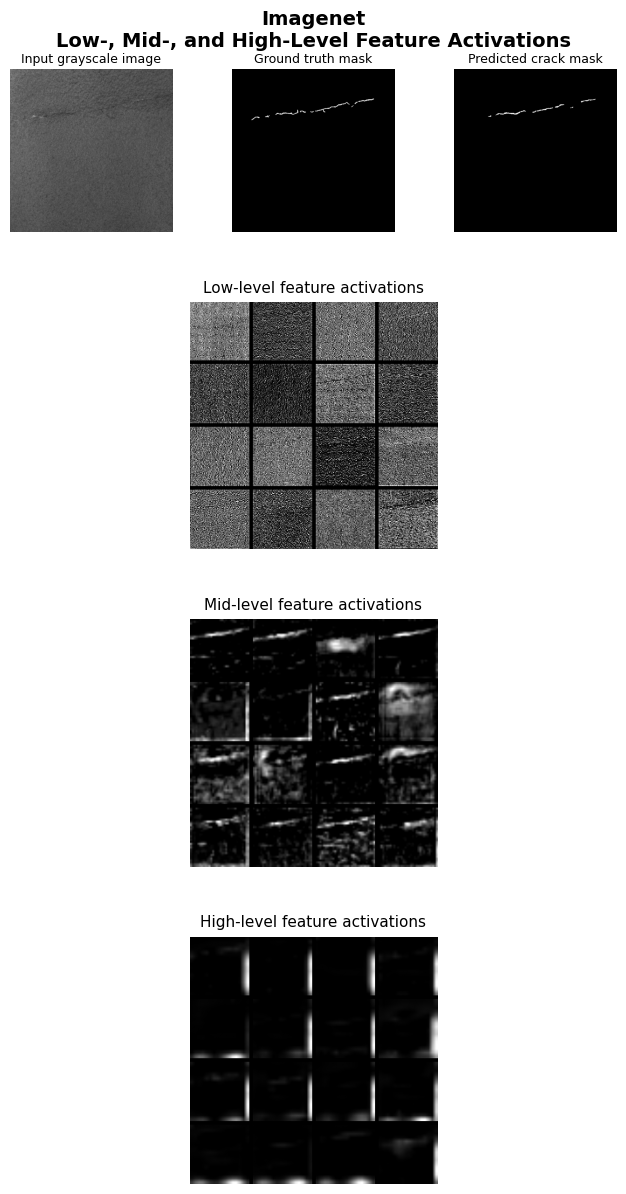


=== Feature extraction: Unet-resnet34-no_weight_Multi-Domain ===
Input tensor for Unet-resnet34-no_weight_Multi-Domain: raw shape=(1, 3, 512, 512), model shape=(1, 3, 512, 512)
Final figure sample split: test
Displaying channel 0 as grayscale. The channels are not treated as RGB.
Saved: /home/yash/Documents/GitHub/CSCI5527-final/fe_multi_model/figures/feature_extraction/all_models/Unet-resnet34-no_weight_Multi-Domain_multilevel_feature_extraction.png at 600 dpi


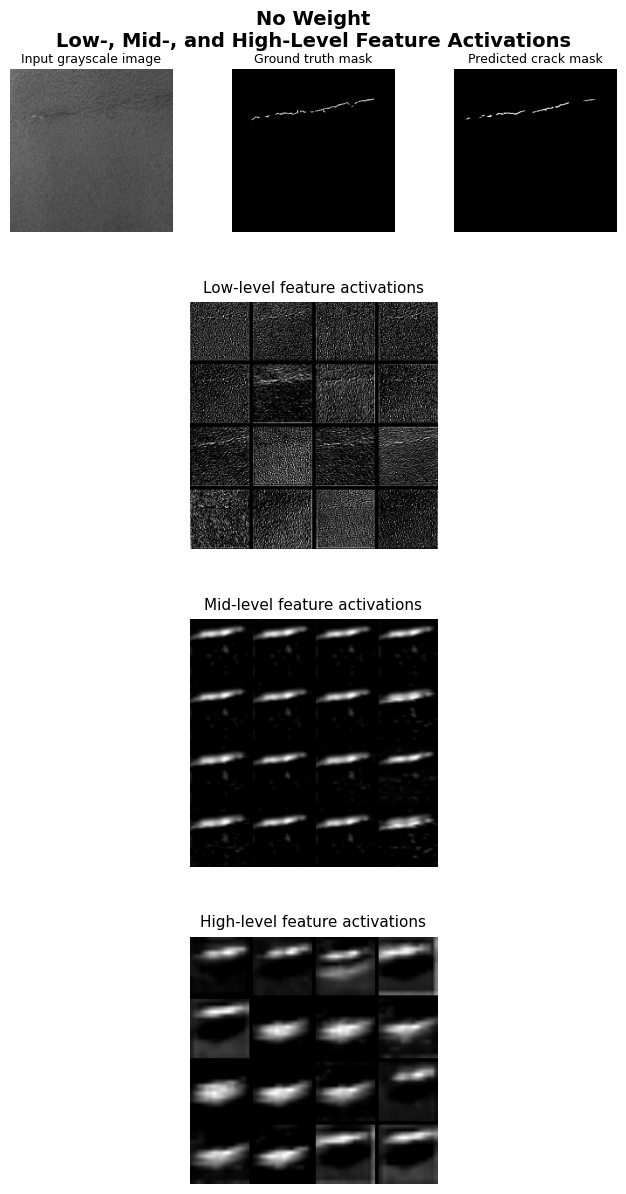


=== Feature extraction: Unet-resnet34-sobelxy_Multi-Domain ===
Input tensor for Unet-resnet34-sobelxy_Multi-Domain: raw shape=(1, 3, 512, 512), model shape=(1, 3, 512, 512)
Final figure sample split: test
Displaying channel 0 as grayscale. The channels are not treated as RGB.
Saved: /home/yash/Documents/GitHub/CSCI5527-final/fe_multi_model/figures/feature_extraction/all_models/Unet-resnet34-sobelxy_Multi-Domain_multilevel_feature_extraction.png at 600 dpi


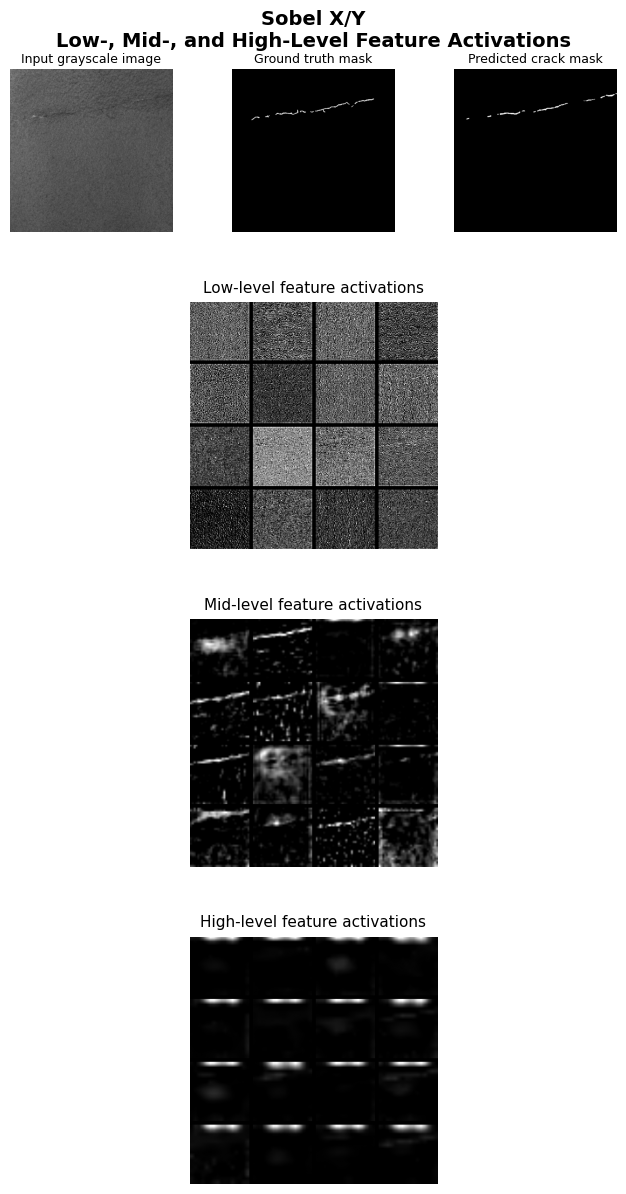


=== Feature extraction: Unet-resnet34-sobelmaglap_Multi-Domain ===
Input tensor for Unet-resnet34-sobelmaglap_Multi-Domain: raw shape=(1, 3, 512, 512), model shape=(1, 3, 512, 512)
Final figure sample split: test
Displaying channel 0 as grayscale. The channels are not treated as RGB.
Saved: /home/yash/Documents/GitHub/CSCI5527-final/fe_multi_model/figures/feature_extraction/all_models/Unet-resnet34-sobelmaglap_Multi-Domain_multilevel_feature_extraction.png at 600 dpi


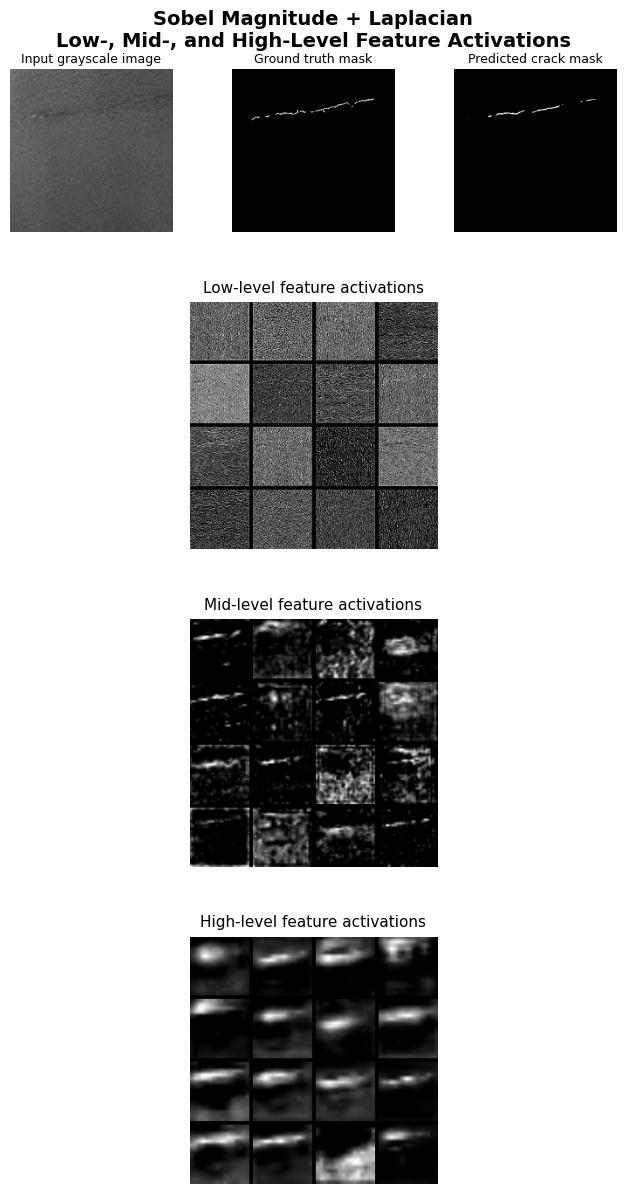


=== Feature extraction: Unet-resnet34-sobelmag_gabor_Multi-Domain ===
Input tensor for Unet-resnet34-sobelmag_gabor_Multi-Domain: raw shape=(1, 3, 512, 512), model shape=(1, 3, 512, 512)
Final figure sample split: test
Displaying channel 0 as grayscale. The channels are not treated as RGB.
Saved: /home/yash/Documents/GitHub/CSCI5527-final/fe_multi_model/figures/feature_extraction/all_models/Unet-resnet34-sobelmag_gabor_Multi-Domain_multilevel_feature_extraction.png at 600 dpi


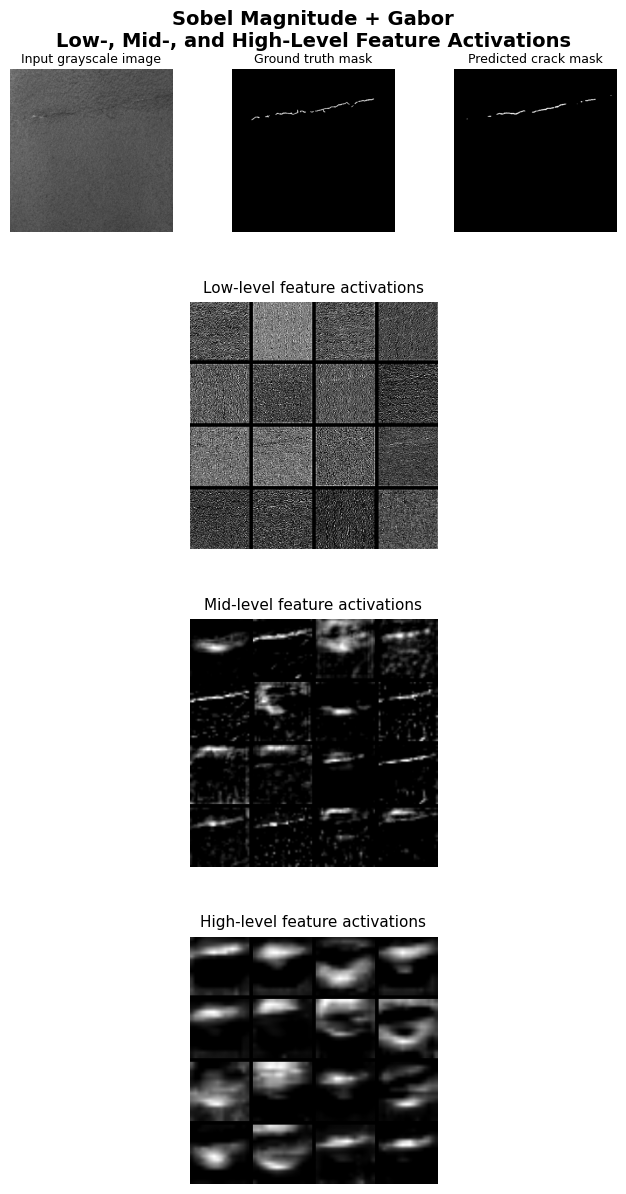


=== Feature extraction summary ===
Saved figures directory: /home/yash/Documents/GitHub/CSCI5527-final/fe_multi_model/figures/feature_extraction/all_models
Run errors: {}
Expected generated files:
 - Unet-resnet34-imagenet_Multi-Domain_multilevel_feature_extraction.png
 - Unet-resnet34-no_weight_Multi-Domain_multilevel_feature_extraction.png
 - Unet-resnet34-sobelmag_gabor_Multi-Domain_multilevel_feature_extraction.png
 - Unet-resnet34-sobelmaglap_Multi-Domain_multilevel_feature_extraction.png
 - Unet-resnet34-sobelxy_Multi-Domain_multilevel_feature_extraction.png


In [12]:
SHOW_FIGURES = True
run_errors = {}

for run in model_runs:
    model_name = run["model_name"]
    print(f"\n=== Feature extraction: {model_name} ===")
    try:
        fig = make_feature_extraction_figure(
            model=run["model"],
            model_name=model_name,
            dataloaders=run["dataloaders"],
            feature_layers=run["feature_layers"],
            device=device,
            custom_stats=run["custom_stats"],
            save_dir=FIGURE_DIR,
            save=True,
            dpi=600,
        )
        if SHOW_FIGURES:
            plt.show()
        else:
            plt.close(fig)
    except Exception as exc:
        run_errors[model_name] = repr(exc)
        print(f"FAILED during feature extraction for {model_name}: {exc}")
        if STRICT:
            raise

print("\n=== Feature extraction summary ===")
print("Saved figures directory:", FIGURE_DIR)
print("Run errors:", run_errors)
print("Expected generated files:")
for p in sorted(FIGURE_DIR.glob("*.png")):
    print(" -", p.name)


Saved stitched comparison: /home/yash/Documents/GitHub/CSCI5527-final/fe_multi_model/figures/feature_extraction/all_models/stitched_five_model_feature_extraction.png
Stitched panels: ['Imagenet', 'No Weight', 'Sobel Magnitude + Gabor', 'Sobel Magnitude + Laplacian', 'Sobel X/Y']
Output size: 6487 x 2464 pixels at 600 dpi


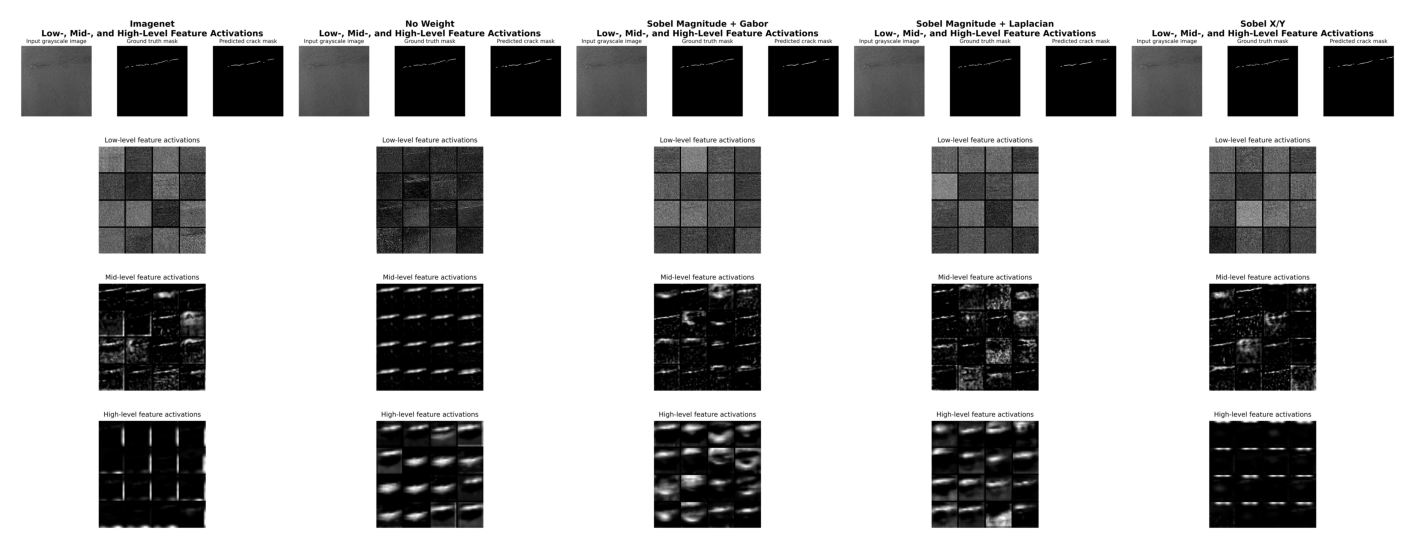

In [13]:
from PIL import Image

STITCH_MODEL_ORDER = [
    "Unet-resnet34-imagenet_Multi-Domain",
    "Unet-resnet34-no_weight_Multi-Domain",
    "Unet-resnet34-sobelmag_gabor_Multi-Domain",
    "Unet-resnet34-sobelmaglap_Multi-Domain",
    "Unet-resnet34-sobelxy_Multi-Domain",
]

STITCH_OUTPUT_PATH = FIGURE_DIR / "stitched_five_model_feature_extraction.png"
STITCH_PANEL_HEIGHT = 2400  # pixel height for each panel in the stitched output
STITCH_PADDING = 32         # white space between panels, in pixels
STITCH_DPI = 600


def _open_on_white(path):
    image = Image.open(path).convert("RGBA")
    white = Image.new("RGBA", image.size, "white")
    white.alpha_composite(image)
    return white.convert("RGB")


panels = []
missing = []

for model_name in STITCH_MODEL_ORDER:
    safe_name = model_name.replace("/", "_").replace(" ", "_")
    path = FIGURE_DIR / f"{safe_name}_multilevel_feature_extraction.png"
    if not path.exists():
        missing.append(path.name)
        continue

    image = _open_on_white(path)
    scale = STITCH_PANEL_HEIGHT / image.height
    new_width = max(1, int(round(image.width * scale)))
    image = image.resize((new_width, STITCH_PANEL_HEIGHT), Image.Resampling.LANCZOS)
    panels.append((model_name, image))

if missing:
    print("Missing individual figure(s); these were not stitched:")
    for name in missing:
        print(" -", name)

if not panels:
    raise RuntimeError(f"No panels found in {FIGURE_DIR}. Run the feature extraction cell first.")

canvas_width = sum(image.width for _, image in panels) + STITCH_PADDING * (len(panels) + 1)
canvas_height = STITCH_PANEL_HEIGHT + 2 * STITCH_PADDING
canvas = Image.new("RGB", (canvas_width, canvas_height), "white")

x = STITCH_PADDING
for _, image in panels:
    canvas.paste(image, (x, STITCH_PADDING))
    x += image.width + STITCH_PADDING

STITCH_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
canvas.save(STITCH_OUTPUT_PATH, dpi=(STITCH_DPI, STITCH_DPI))
print(f"Saved stitched comparison: {STITCH_OUTPUT_PATH}")
print(f"Stitched panels: {[pretty_model_title(name) for name, _ in panels]}")
print(f"Output size: {canvas.size[0]} x {canvas.size[1]} pixels at {STITCH_DPI} dpi")

# Display a preview in the notebook.
plt.figure(figsize=(18, 10), facecolor="white")
plt.imshow(canvas)
plt.axis("off")
plt.show()
